In [1]:
import os
import pandas as pd
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
NOTEBOOK_DIR = os.getcwd()

# golfDB.mat is bundled in this folder
GOLFDB_MAT = os.path.join(NOTEBOOK_DIR, "golfDB.mat")

# Videos from the main team repo, cloned alongside this folder
VIDEO_DIR = os.path.abspath(os.path.join(
    NOTEBOOK_DIR, "..",
    "Data", "videos_160"
))

print("GOLFDB_MAT:", GOLFDB_MAT, "| exists:", os.path.exists(GOLFDB_MAT))
print("VIDEO_DIR: ", VIDEO_DIR,  "| exists:", os.path.exists(VIDEO_DIR))

GOLFDB_MAT: /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/AL EDA Investigation/golfDB.mat | exists: True
VIDEO_DIR:  /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/Data/videos_160 | exists: True


In [3]:
def unwrap(x):
    while isinstance(x, np.ndarray) and x.size == 1:
        x = x.item()
    return x

mat = sio.loadmat(GOLFDB_MAT)
golfdb = mat["golfDB"]

rows = []
for i in range(golfdb.shape[1]):
    record = golfdb[0, i]
    rows.append({field: unwrap(record[field]) for field in golfdb.dtype.names})

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} records")
print("Views:", df['view'].value_counts().to_dict())
df.head()

Loaded 1400 records
Views: {'down-the-line': 585, 'face-on': 461, 'other': 354}


,id,youtube_id,player,sex,club,view,slow,events,bbox,split
0,0,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,0,"[[408, 455, 473, 476, 490, 495, 498, 501, 514,...","[[0.09765625000000001, 0.006944444444444444, 0...",3
1,1,f1BWA5F87Jc,SANDRA GAL,f,driver,down-the-line,1,"[[814, 854, 917, 931, 988, 1006, 1019, 1030, 1...","[[0.039062500000000014, 0.0006944444444444445,...",3
2,2,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,0,"[[521, 659, 678, 683, 692, 696, 698, 701, 715,...","[[0.165625, 0.0006944444444444445, 0.48359375,...",3
3,3,tA1iotgtMyc,CHRIS DIMARCO,m,driver,down-the-line,1,"[[1106, 1190, 1244, 1264, 1300, 1313, 1324, 13...","[[0.18515625, 0.0006944444444444445, 0.465625,...",3
4,4,wDCKLePrwHA,BROOKE HENDERSON,f,driver,down-the-line,0,"[[157, 170, 183, 188, 197, 201, 205, 207, 220,...","[[0.11015625, 0.0006944444444444445, 0.4984375...",3


## Step 1 — Player-View Inventory

Build a matrix of players × views to find who has rich multi-view coverage.
Down-the-line and face-on are the two views we care about for 2D→3D mapping:
together they capture all three spatial axes.

In [4]:
# Only keep the two informative views
key_views = ['down-the-line', 'face-on']
df_kv = df[df['view'].isin(key_views)].copy()

# Player × view counts
view_matrix = pd.crosstab(df_kv['player'], df_kv['view'])
view_matrix['total'] = view_matrix.sum(axis=1)
view_matrix = view_matrix.sort_values('total', ascending=False)

# Players with BOTH views present
view_matrix['has_both'] = (
    (view_matrix.get('down-the-line', 0) > 0) &
    (view_matrix.get('face-on', 0) > 0)
)

print(f"Players with both key views: {view_matrix['has_both'].sum()} / {len(view_matrix)}")
print()
print("Top 20 players by total key-view swings:")
view_matrix.head(20)

Players with both key views: 93 / 202

Top 20 players by total key-view swings:


view,down-the-line,face-on,total,has_both
player,,,,
LYDIA KO,24,30,54,True
MICHELLE WIE,17,24,41,True
BROOKE HENDERSON,12,13,25,True
LEXI THOMPSON,15,8,23,True
INBEE PARK,12,9,21,True
TIGER WOODS,9,9,18,True
RORY MCILROY,14,2,16,True
CHARLEY HULL,6,9,15,True
GRAEME MCDOWELL,8,7,15,True


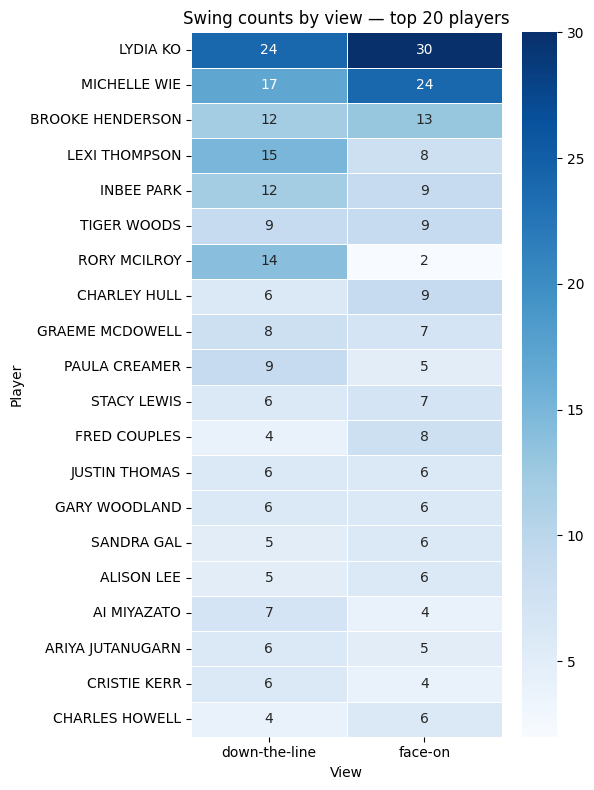

In [5]:
top_n = 20
top_players = view_matrix.head(top_n)
heat_data = top_players[key_views].fillna(0)

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    heat_data,
    annot=True, fmt='g', cmap='Blues',
    linewidths=0.5, ax=ax
)
ax.set_title(f'Swing counts by view — top {top_n} players')
ax.set_xlabel('View')
ax.set_ylabel('Player')
plt.tight_layout()
plt.show()

In [6]:
player = 'TIGER WOODS'
tiger = df[df['player'] == player]

print(f"{player} — {len(tiger)} total records")
print()
print("View breakdown:")
print(tiger['view'].value_counts())
print()
print("Club breakdown:")
print(tiger['club'].value_counts())
print()
print("Slow-motion breakdown:")
print(tiger['slow'].value_counts())
print()
print("Unique youtube_ids:", tiger['youtube_id'].nunique())

TIGER WOODS — 53 total records

View breakdown:
view
other            35
face-on           9
down-the-line     9
Name: count, dtype: int64

Club breakdown:
club
iron       27
driver     16
fairway     9
wedge       1
Name: count, dtype: int64

Slow-motion breakdown:
slow
0    32
1    21
Name: count, dtype: int64

Unique youtube_ids: 20


## Step 2 — youtube_id Overlap Analysis

Records sharing the same `youtube_id` came from the same source video.
If that video contains both a down-the-line and a face-on clip of the same swing,
those two records are our best candidate for pseudo-stereo 3D reconstruction —
we can align them by event frame (semantic keyframe) rather than raw timestamp.

In [7]:
# For each (player, youtube_id), collect which views are present
yt_groups = (
    df.groupby(['player', 'youtube_id'])
    .agg(
        views=('view', lambda x: sorted(x.unique().tolist())),
        n_records=('view', 'count'),
        clubs=('club', lambda x: sorted(x.unique().tolist())),
        slow_values=('slow', lambda x: sorted(x.unique().tolist())),
    )
    .reset_index()
)

yt_groups['n_views'] = yt_groups['views'].apply(len)
yt_groups['has_dtl'] = yt_groups['views'].apply(lambda v: 'down-the-line' in v)
yt_groups['has_fo']  = yt_groups['views'].apply(lambda v: 'face-on' in v)
yt_groups['dtl_and_fo'] = yt_groups['has_dtl'] & yt_groups['has_fo']

multi = yt_groups[yt_groups['dtl_and_fo']].sort_values('n_records', ascending=False)

print(f"youtube_ids with BOTH down-the-line AND face-on: {len(multi)}")
print(f"Unique players represented: {multi['player'].nunique()}")
print()
multi.head(10)

youtube_ids with BOTH down-the-line AND face-on: 43
Unique players represented: 36



,player,youtube_id,views,n_records,clubs,slow_values,n_views,has_dtl,has_fo,dtl_and_fo
397,MICHELLE WIE,IVRbQrq2JHo,"[down-the-line, face-on, other]",16,"[driver, fairway, iron]","[0, 1]",3,True,True,True
62,BERNHARD LANGER,bMVf3lKrUlo,"[down-the-line, face-on, other]",15,"[driver, hybrid, iron]","[0, 1]",3,True,True,True
179,FRED COUPLES,XIzyJGDBuqc,"[down-the-line, face-on, other]",14,"[driver, fairway, hybrid, iron]","[0, 1]",3,True,True,True
450,PHIL MICKELSON,wrvEURqD-GI,"[down-the-line, face-on, other]",11,"[fairway, iron, wedge]","[0, 1]",3,True,True,True
194,GRAEME MCDOWELL,8HJXWpyYWVE,"[down-the-line, face-on]",8,"[driver, fairway]","[0, 1]",2,True,True,True
110,BUBBA WATSON,skkF2JsuLWM,"[down-the-line, face-on, other]",8,"[driver, iron]",[0],3,True,True,True
370,LYDIA KO,ghi3184d6Is,"[down-the-line, face-on]",8,[driver],"[0, 1]",2,True,True,True
4,ADAM SCOTT,t-DfeLMz6Rc,"[down-the-line, face-on]",7,"[driver, iron, wedge]","[0, 1]",2,True,True,True
437,PAULA CREAMER,Cf3vKhXDY8w,"[down-the-line, face-on, other]",7,"[driver, iron]","[0, 1]",3,True,True,True
254,JASON DAY,EBw9BdZmKrs,"[down-the-line, face-on, other]",7,"[driver, fairway]","[0, 1]",3,True,True,True


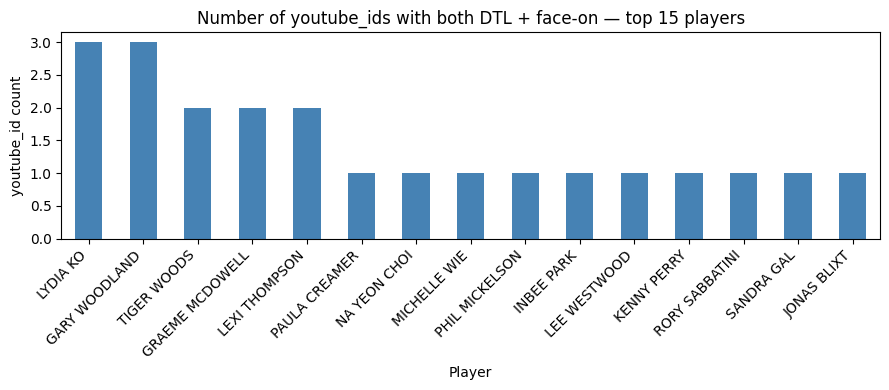

In [8]:
multi_by_player = (
    multi.groupby('player')['youtube_id']
    .count()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 4))
multi_by_player.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of youtube_ids with both DTL + face-on — top 15 players')
ax.set_xlabel('Player')
ax.set_ylabel('youtube_id count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
tiger_multi = multi[multi['player'] == 'TIGER WOODS'].reset_index(drop=True)

print(f"Tiger Woods — youtube_ids with both DTL + face-on: {len(tiger_multi)}")
print()
tiger_multi[['youtube_id', 'views', 'n_records', 'clubs', 'slow_values']]

Tiger Woods — youtube_ids with both DTL + face-on: 2



,youtube_id,views,n_records,clubs,slow_values
0,blonNcv1yas,"[down-the-line, face-on, other]",6,"[driver, fairway, iron, wedge]",[0]
1,H9MWcs3YS-I,"[down-the-line, face-on, other]",5,"[driver, iron]",[0]


In [10]:
# Expand tiger_multi into explicit (dtl_id, fo_id) pairs
id_rows = []
for _, group_row in tiger_multi.iterrows():
    yt = group_row['youtube_id']
    records = df[df['youtube_id'] == yt]
    dtl_recs = records[records['view'] == 'down-the-line']
    fo_recs  = records[records['view'] == 'face-on']
    for _, d in dtl_recs.iterrows():
        for _, f in fo_recs.iterrows():
            id_rows.append({
                'youtube_id': yt,
                'dtl_id':    int(d['id']),
                'fo_id':     int(f['id']),
                'club':      d['club'],
                'dtl_slow':  int(d['slow']),
                'fo_slow':   int(f['slow']),
            })

id_pairs = pd.DataFrame(id_rows)
print(f"Total DTL/FO record pairs for Tiger Woods: {len(id_pairs)}")
print()
id_pairs

Total DTL/FO record pairs for Tiger Woods: 4



,youtube_id,dtl_id,fo_id,club,dtl_slow,fo_slow
0,blonNcv1yas,518,521,iron,0,0
1,blonNcv1yas,520,521,iron,0,0
2,H9MWcs3YS-I,1103,1100,driver,0,0
3,H9MWcs3YS-I,1103,1104,driver,0,0


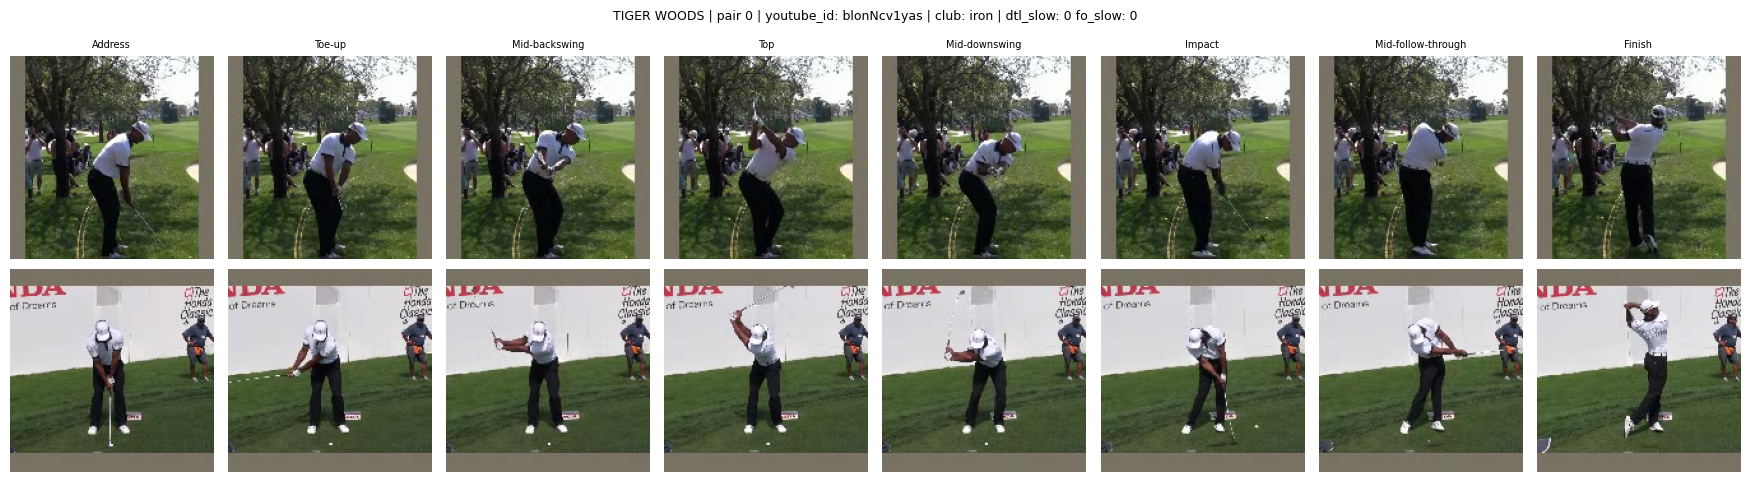

DTL record id: 518  |  Face-on record id: 521


In [11]:
import cv2

SWING_EVENT_NAMES = [
    'Address', 'Toe-up', 'Mid-backswing', 'Top',
    'Mid-downswing', 'Impact', 'Mid-follow-through', 'Finish'
]

def get_swing_frames(video_path, events_raw):
    """Return the 8 named swing-event frames from a video as RGB arrays."""
    e = np.array(events_raw).flatten().astype(int)
    relative = e - e[0]          # shift so clip starts at frame 0
    swing_frames = relative[1:9] # skip clip_start / clip_end
    cap = cv2.VideoCapture(video_path)
    frames = []
    for idx in swing_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret
                      else np.zeros((160, 120, 3), dtype=np.uint8))
    cap.release()
    return frames


def show_swing_pair(pair_idx=0):
    """Display the 8 swing-event frames for both DTL and face-on views.
    Change pair_idx to browse other matched pairs."""
    row = id_pairs.iloc[pair_idx]
    dtl_rec = df[df['id'] == row['dtl_id']].iloc[0]
    fo_rec  = df[df['id'] == row['fo_id']].iloc[0]

    dtl_path = os.path.join(VIDEO_DIR, f"{int(row['dtl_id'])}.mp4")
    fo_path  = os.path.join(VIDEO_DIR, f"{int(row['fo_id'])}.mp4")

    dtl_frames = get_swing_frames(dtl_path, dtl_rec['events'])
    fo_frames  = get_swing_frames(fo_path,  fo_rec['events'])

    n = len(SWING_EVENT_NAMES)
    fig, axes = plt.subplots(2, n, figsize=(n * 2.2, 5))

    for col, name in enumerate(SWING_EVENT_NAMES):
        axes[0, col].imshow(dtl_frames[col])
        axes[0, col].set_title(name, fontsize=7)
        axes[0, col].axis('off')
        axes[1, col].imshow(fo_frames[col])
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('DTL', fontsize=9, rotation=0, labelpad=40)
    axes[1, 0].set_ylabel('Face-on', fontsize=9, rotation=0, labelpad=40)

    fig.suptitle(
        f"TIGER WOODS | pair {pair_idx} | youtube_id: {row['youtube_id']} "
        f"| club: {row['club']} | dtl_slow: {row['dtl_slow']} fo_slow: {row['fo_slow']}",
        fontsize=9
    )
    plt.tight_layout()
    plt.show()
    print(f"DTL record id: {int(row['dtl_id'])}  |  Face-on record id: {int(row['fo_id'])}")


# Change pair_idx (0 to len(id_pairs)-1) to browse all matched pairs
show_swing_pair(pair_idx=0)

In [12]:
# Pick the first matched youtube_id and inspect the actual records
sample_yt = tiger_multi.iloc[0]['youtube_id']
sample_records = df[df['youtube_id'] == sample_yt].copy()

print(f"youtube_id: {sample_yt}")
print(f"Records: {len(sample_records)}")
print()

# Show view, club, slow, and event frame range for each record
def event_range(events):
    e = np.array(events).flatten().astype(int)
    return f"{e[0]}–{e[-1]} ({e[-1]-e[0]} frames)"

sample_records['event_range'] = sample_records['events'].apply(event_range)
sample_records[['id', 'view', 'club', 'slow', 'event_range', 'split']]


youtube_id: blonNcv1yas
Records: 6



,id,view,club,slow,event_range,split
516,516,other,iron,0,361–587 (226 frames),1
517,517,other,driver,0,3137–3379 (242 frames),1
518,518,down-the-line,iron,0,3979–4185 (206 frames),1
519,519,other,fairway,0,4515–4682 (167 frames),1
520,520,down-the-line,iron,0,5192–5499 (307 frames),1
521,521,face-on,wedge,0,6129–6360 (231 frames),1


### Event-frame alignment

Since DTL and face-on clips are not time-synchronized, we align them by
**swing event** (Address, Top, Impact, etc.) rather than raw frame number.
The 10 GolfDB annotations give us 8 named keyframes that are comparable across clips.

In [13]:
EVENT_NAMES = [
    'clip_start', 'address', 'toe_up', 'mid_backswing',
    'top', 'mid_downswing', 'impact', 'mid_follow_through',
    'finish', 'clip_end'
]

def events_to_dict(events):
    e = np.array(events).flatten().astype(int)
    relative = e - e[0]  # shift so clip starts at frame 0
    return dict(zip(EVENT_NAMES, relative.tolist()))

# Build event table for the sample youtube_id
event_rows = []
for _, row in sample_records.iterrows():
    edict = events_to_dict(row['events'])
    edict['view'] = row['view']
    edict['record_id'] = int(row['id'])
    edict['slow'] = int(row['slow'])
    event_rows.append(edict)

event_df = pd.DataFrame(event_rows).set_index(['record_id', 'view', 'slow'])
print("Relative event frames per record (frame 0 = clip start):")
event_df

Relative event frames per record (frame 0 = clip start):


,,,clip_start,address,toe_up,mid_backswing,top,mid_downswing,impact,mid_follow_through,finish,clip_end
record_id,view,slow,,,,,,,,,,
516,other,0,0,147,158,161,169,173,175,177,196,226
517,other,0,0,135,148,151,158,162,165,167,182,242
518,down-the-line,0,0,134,144,147,155,159,162,165,174,206
519,other,0,0,61,74,77,84,88,91,93,107,167
520,down-the-line,0,0,196,209,212,219,224,227,229,247,307
521,face-on,0,0,145,157,161,168,172,175,177,192,231


## Step 3 — Z Consistency Across Tiger's DTL Swings

Since same-`youtube_id` pairs are different swing instances, we shift to a
distributional question: **how consistent is MediaPipe's estimated Z coordinate
for each joint at each swing event across all of Tiger's DTL swings?**

Low std dev → MediaPipe agrees with itself → that (event, joint) pair is a
reliable depth signal we can use as a prior.  
High std dev → depth is noisy or ambiguous at that moment in the swing.

In [14]:
import mediapipe as mp
import cv2
import pathlib

mp_pose = mp.solutions.pose

SWING_EVENT_NAMES = [
    'Address', 'Toe-up', 'Mid-backswing', 'Top',
    'Mid-downswing', 'Impact', 'Mid-follow-through', 'Finish'
]

# Golf-relevant joints (MediaPipe landmark indices)
KEY_JOINTS = {
    11: 'L_Shoulder', 12: 'R_Shoulder',
    13: 'L_Elbow',    14: 'R_Elbow',
    15: 'L_Wrist',    16: 'R_Wrist',
    23: 'L_Hip',      24: 'R_Hip',
    25: 'L_Knee',     26: 'R_Knee',
}

tiger_dtl = df[
    (df['player'] == 'TIGER WOODS') & (df['view'] == 'down-the-line')
].reset_index(drop=True)

print(f'Tiger Woods DTL swings to process: {len(tiger_dtl)}')
tiger_dtl[['id', 'club', 'slow', 'youtube_id']].head(10)

Tiger Woods DTL swings to process: 9


,id,club,slow,youtube_id
0,47,iron,0,4HzLO88ryCU
1,48,iron,1,4HzLO88ryCU
2,269,driver,0,ppDvhlGr5nI
3,270,driver,1,ppDvhlGr5nI
4,518,iron,0,blonNcv1yas
5,520,iron,0,blonNcv1yas
6,1103,driver,0,H9MWcs3YS-I
7,1215,iron,0,W0YUPZGGQ34
8,1216,iron,1,W0YUPZGGQ34


In [15]:
def extract_world_landmarks_at_events(record, video_dir):
    """
    Run MediaPipe on each of the 8 swing-event frames for one record.
    Returns a list of rows (one per joint per event).
    """
    video_id = int(record['id'])
    video_path = os.path.join(video_dir, f"{video_id}.mp4")

    e = np.array(record['events']).flatten().astype(int)
    relative = e - e[0]
    event_frames = relative[1:9]  # skip clip_start / clip_end

    rows = []
    cap = cv2.VideoCapture(video_path)

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        min_detection_confidence=0.5
    ) as pose:
        for event_idx, frame_num in enumerate(event_frames):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_num))
            ret, frame = cap.read()
            if not ret:
                continue
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)
            if not results.pose_world_landmarks:
                continue
            for joint_idx, lm in enumerate(results.pose_world_landmarks.landmark):
                rows.append({
                    'record_id':  video_id,
                    'club':       record['club'],
                    'slow':       int(record['slow']),
                    'event_idx':  event_idx,
                    'event_name': SWING_EVENT_NAMES[event_idx],
                    'joint_idx':  joint_idx,
                    'x': lm.x, 'y': lm.y, 'z': lm.z,
                    'visibility': lm.visibility,
                })

    cap.release()
    return rows

In [16]:
all_rows = []
n = len(tiger_dtl)

for i, (_, record) in enumerate(tiger_dtl.iterrows()):
    rows = extract_world_landmarks_at_events(record, VIDEO_DIR)
    all_rows.extend(rows)
    print(f"  [{i+1:2d}/{n}] record {int(record['id']):4d} "
          f"| club: {record['club']:8s} | slow: {int(record['slow'])} "
          f"| landmark rows: {len(rows)}")

landmarks_df = pd.DataFrame(all_rows)
landmarks_df['event_name'] = pd.Categorical(
    landmarks_df['event_name'], categories=SWING_EVENT_NAMES, ordered=True
)

# Save to Combined_3D_Data/
out_dir = os.path.join(NOTEBOOK_DIR, 'Combined_3D_Data')
pathlib.Path(out_dir).mkdir(exist_ok=True)
out_path = os.path.join(out_dir, 'tiger_dtl_world_landmarks.csv')
landmarks_df.to_csv(out_path, index=False)

print(f'\nTotal rows: {len(landmarks_df)}')
print(f'Saved → {out_path}')
landmarks_df.head()

I0000 00:00:1780242893.230428       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


  [ 1/9] record   47 | club: iron     | slow: 0 | landmark rows: 264


I0000 00:00:1780242893.845964       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


  [ 2/9] record   48 | club: iron     | slow: 1 | landmark rows: 264


I0000 00:00:1780242894.430684       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


...

I0000 00:00:1780242897.545143       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


  [ 8/9] record 1215 | club: iron     | slow: 0 | landmark rows: 264


I0000 00:00:1780242898.138677       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5


  [ 9/9] record 1216 | club: iron     | slow: 1 | landmark rows: 264

Total rows: 2376
Saved → /Users/austinblee/github/capstone/SinglePOVGolfSwingReconstructionUsingSimulatedBiomechanicalAI/AL EDA Investigation/Combined_3D_Data/tiger_dtl_world_landmarks.csv


,record_id,club,slow,event_idx,event_name,joint_idx,x,y,z,visibility
0,47,iron,0,0,Address,0,0.454316,-0.310279,-0.144160,0.999956
1,47,iron,0,0,Address,1,0.468451,-0.345128,-0.144153,0.999912
2,47,iron,0,0,Address,2,0.470850,-0.342768,-0.132969,0.999911
3,47,iron,0,0,Address,3,0.470617,-0.342973,-0.136847,0.999930
4,47,iron,0,0,Address,4,0.474573,-0.343325,-0.187620,0.999947


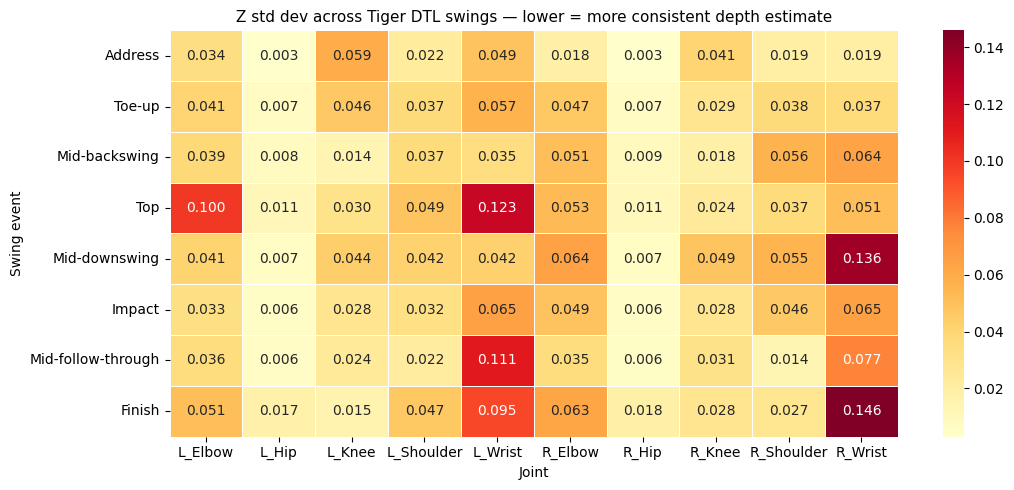

Most consistent (event, joint) pairs:
        event_name joint_name    z_std
           Address      L_Hip 0.003043
           Address      R_Hip 0.003381
Mid-follow-through      R_Hip 0.005621
            Impact      L_Hip 0.005773
Mid-follow-through      L_Hip 0.005898
            Impact      R_Hip 0.005962
     Mid-downswing      L_Hip 0.006547
     Mid-downswing      R_Hip 0.006737
            Toe-up      L_Hip 0.007016
            Toe-up      R_Hip 0.007141

Least consistent (event, joint) pairs:
        event_name joint_name    z_std
            Finish    R_Wrist 0.145938
     Mid-downswing    R_Wrist 0.136346
               Top    L_Wrist 0.123178
Mid-follow-through    L_Wrist 0.111173
               Top    L_Elbow 0.099849
            Finish    L_Wrist 0.095119
Mid-follow-through    R_Wrist 0.076915
            Impact    L_Wrist 0.064876
            Impact    R_Wrist 0.064663
     Mid-downswing    R_Elbow 0.064402


In [17]:
key_df = landmarks_df[landmarks_df['joint_idx'].isin(KEY_JOINTS)].copy()
key_df['joint_name'] = key_df['joint_idx'].map(KEY_JOINTS)

z_std = (
    key_df.groupby(['event_name', 'joint_name'], observed=True)['z']
    .std()
    .unstack('joint_name')
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    z_std, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.4, ax=ax
)
ax.set_title(
    'Z std dev across Tiger DTL swings — lower = more consistent depth estimate',
    fontsize=11
)
ax.set_xlabel('Joint')
ax.set_ylabel('Swing event')
plt.tight_layout()
plt.show()

print('Most consistent (event, joint) pairs:')
z_std_flat = z_std.stack().rename('z_std').reset_index()
print(z_std_flat.sort_values('z_std').head(10).to_string(index=False))

print('\nLeast consistent (event, joint) pairs:')
print(z_std_flat.sort_values('z_std', ascending=False).head(10).to_string(index=False))

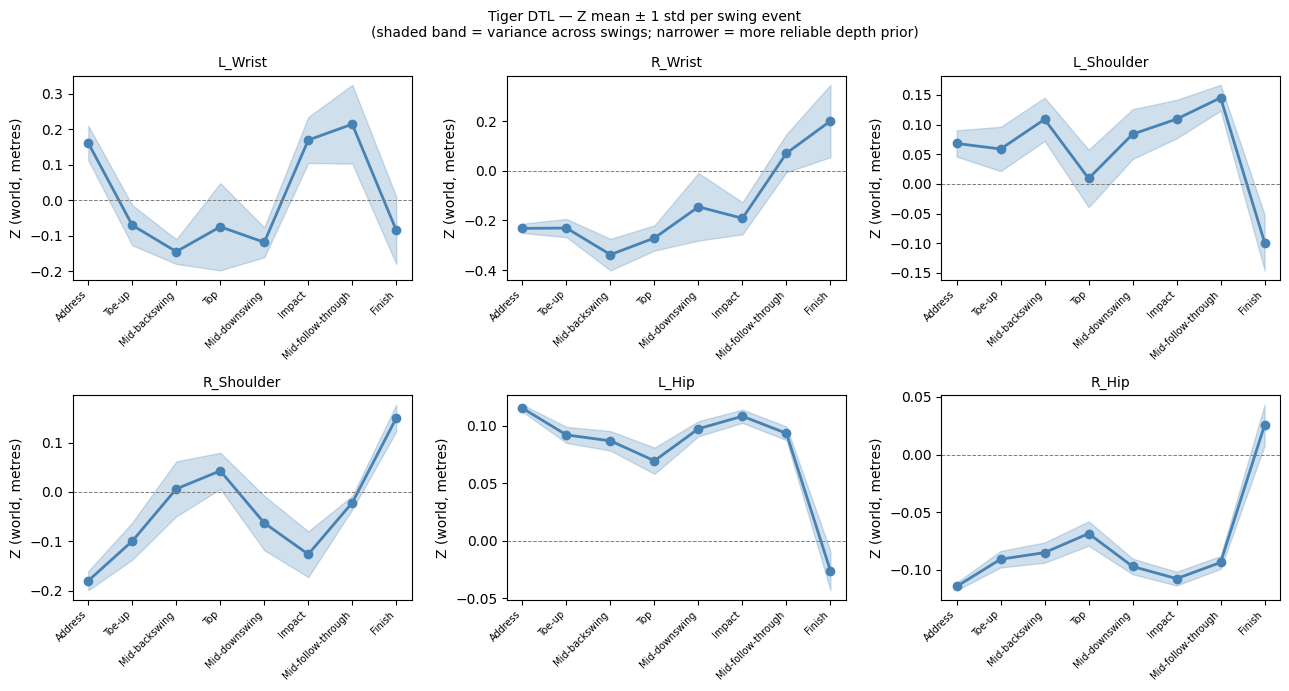

In [18]:
# Z mean ± 1 std across swing events for golf's most important joints
FOCUS = [15, 16, 11, 12, 23, 24]  # wrists, shoulders, hips
focus_df = key_df[key_df['joint_idx'].isin(FOCUS)].copy()

z_mean = (
    focus_df.groupby(['event_name', 'joint_name'], observed=True)['z']
    .agg(['mean', 'std'])
    .reset_index()
)

joint_order = ['L_Wrist', 'R_Wrist', 'L_Shoulder', 'R_Shoulder', 'L_Hip', 'R_Hip']
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)

for ax, jname in zip(axes.flat, joint_order):
    jdf = z_mean[z_mean['joint_name'] == jname]
    events = jdf['event_name'].tolist()
    x = range(len(events))
    ax.plot(x, jdf['mean'], marker='o', color='steelblue', linewidth=2)
    ax.fill_between(
        x,
        jdf['mean'] - jdf['std'],
        jdf['mean'] + jdf['std'],
        alpha=0.25, color='steelblue'
    )
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_title(jname, fontsize=10)
    ax.set_xticks(list(x))
    ax.set_xticklabels(events, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('Z (world, metres)')

fig.suptitle(
    'Tiger DTL — Z mean ± 1 std per swing event\n'
    '(shaded band = variance across swings; narrower = more reliable depth prior)',
    fontsize=10
)
plt.tight_layout()
plt.show()

/var/folders/qy/gnlb8t1943b5mspq_yr0bsh80000gn/T/ipykernel_73938/2689313290.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=SWING_EVENT_NAMES, patch_artist=True,
/var/folders/qy/gnlb8t1943b5mspq_yr0bsh80000gn/T/ipykernel_73938/2689313290.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=SWING_EVENT_NAMES, patch_artist=True,


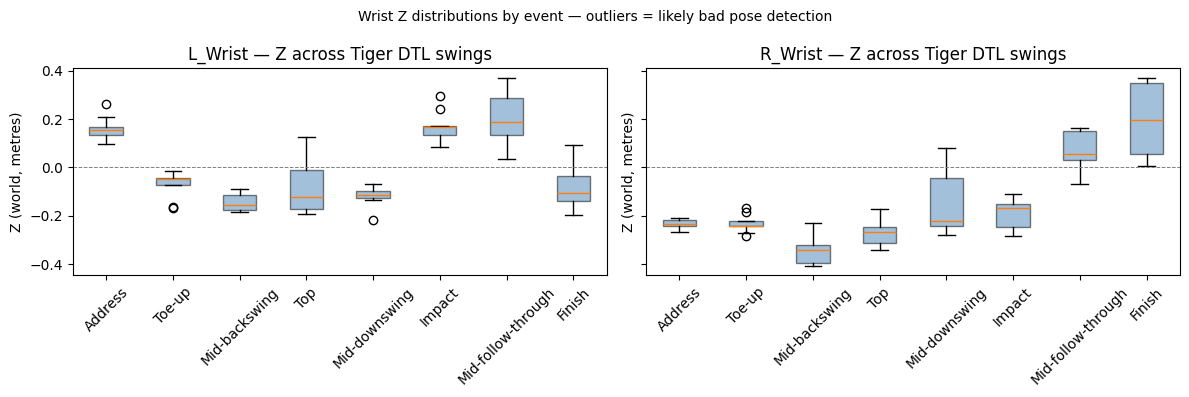

In [19]:
# Box plots let you see outliers — useful for spotting bad MP detections
wrist_df = key_df[key_df['joint_idx'].isin([15, 16])].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (jidx, jname) in zip(axes, [(15, 'L_Wrist'), (16, 'R_Wrist')]):
    sub = wrist_df[wrist_df['joint_idx'] == jidx]
    sub = sub.sort_values('event_name')
    groups = [sub[sub['event_name'] == e]['z'].values for e in SWING_EVENT_NAMES]
    ax.boxplot(groups, labels=SWING_EVENT_NAMES, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(f'{jname} — Z across Tiger DTL swings')
    ax.set_ylabel('Z (world, metres)')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

plt.suptitle('Wrist Z distributions by event — outliers = likely bad pose detection', fontsize=10)
plt.tight_layout()
plt.show()